# 🛠 Notebook 04 — Feature Engineering

**Purpose:** Transform the master dataset into model-ready features with economic justification.

## Input → Output

- **Input:** `data/interim/fx_master_dataset.csv` (4108 × 24)
- **Output:** `data/processed/fx_features.csv` (model-ready features + target)

## Feature Groups

| Group | Examples | Why |
|---|---|---|
| Returns | dxy_return, gold_return | Stationarity (prices have trends) |
| Differences | dgs2_diff, vixcls_diff | Rates already in %, use change |
| Lag features | dxy_return_lag1, eurusd_return_lag1 | Model predicts tomorrow from today + past |
| Rolling stats | eurusd_ma_7, eurusd_vol_14 | Smoothed trend + volatility regime |
| Engineered | us_eu_rate_spread, vix_regime | Direct economic logic |

## Feature Selection Basis

Features selected from **Notebook 03 (Cross-Asset Analysis)** findings:
- **Tier 1:** dxy, vixcls, dgs2, eur_net_position (high MI + economic theory)
- **Tier 2:** gold, oil, t10yie, ecbdfr (moderate)
- **Engineered:** spreads, regimes, lags

## Target

- `target_return_next_day`: next-day EUR/USD log return
- `target_direction`: 1 if next-day return > 0, else 0 (UP/DOWN)

---

**Author:** Dong Cong Gia Khang  
**Date:** June 2026

## 1. Setup

In [1]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = PROJECT_ROOT / "figures" / "features"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed output: {PROCESSED_DIR}")
print(f"Figures: {FIG_DIR}")

Project root: c:\Users\Khang\Desktop\Final Project 2
Processed output: c:\Users\Khang\Desktop\Final Project 2\data\processed
Figures: c:\Users\Khang\Desktop\Final Project 2\figures\features


In [2]:
"""
Load the master dataset.
"""
df = pd.read_csv(
    INTERIM_DIR / "fx_master_dataset.csv",
    parse_dates=["date"],
).sort_values("date").reset_index(drop=True)

print(f"Master dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

Master dataset shape: (4107, 24)
Date range: 2010-01-04 -> 2026-05-13

Columns (24):
  - date
  - eurusd
  - dxy
  - gold
  - oil
  - cp0000ez19m086nest
  - cpiaucsl
  - dexuseu
  - dff
  - dgs10
  - dgs2
  - dtwexbgs
  - ecbdfr
  - irltlt01ezm156n
  - payems
  - t10yie
  - unrate
  - vixcls
  - ester_overnight
  - eur_effective_rate
  - euribor_3m
  - eurusd_official
  - eur_net_position
  - eur_net_position_pct


## 2. Group 1 — Returns (Price Series)

Convert price series to **log returns** for stationarity.

Formula: `return_t = ln(price_t / price_{t-1})`

Why log returns:
- Prices have trends → non-stationary → bad for ML
- Returns are stationary (proven in Notebook 02)
- Log returns are additive across time

Applied to: eurusd, dxy, gold, oil

In [3]:
"""
Group 1: Log returns for price series.
"""
# Start building features into a new dataframe
feat = pd.DataFrame()
feat["date"] = df["date"]

# Price series -> log returns
price_cols = ["eurusd", "dxy", "gold", "oil"]
for col in price_cols:
    feat[f"{col}_return"] = np.log(df[col] / df[col].shift(1))

print("Group 1 — Returns created:")
for col in price_cols:
    print(f"  - {col}_return")

print(f"\nSample (last 3 rows):")
print(feat[[f"{c}_return" for c in price_cols]].tail(3).to_string())

Group 1 — Returns created:
  - eurusd_return
  - dxy_return
  - gold_return
  - oil_return

Sample (last 3 rows):
      eurusd_return  dxy_return  gold_return  oil_return
4104       0.000942    0.001022    -0.000360    0.027393
4105      -0.003786    0.003567    -0.008748    0.041054
4106      -0.001735    0.001931     0.004288   -0.011417


## 3. Group 2 — Differences (Rate / Index Series)

For rates and indices (already in % or index units), use **first difference** instead of returns.

Formula: `diff_t = value_t - value_{t-1}`

Why difference (not return):
- Rates are already in % (e.g., DGS2 = 4.5%)
- A change from 4.5% to 4.6% is meaningful as +0.1, not as a ratio
- VIX, yields, positioning → use difference

Applied to: vixcls, dgs2, dgs10, ecbdfr, t10yie, eur_effective_rate, dtwexbgs

In [4]:
"""
Group 2: First differences for rate/index series.
"""
diff_cols = ["vixcls", "dgs2", "dgs10", "ecbdfr", "t10yie",
             "eur_effective_rate", "dtwexbgs"]

for col in diff_cols:
    feat[f"{col}_diff"] = df[col].diff()

print("Group 2 — Differences created:")
for col in diff_cols:
    print(f"  - {col}_diff")

print(f"\nSample (last 3 rows):")
print(feat[[f"{c}_diff" for c in diff_cols]].tail(3).to_string())

Group 2 — Differences created:
  - vixcls_diff
  - dgs2_diff
  - dgs10_diff
  - ecbdfr_diff
  - t10yie_diff
  - eur_effective_rate_diff
  - dtwexbgs_diff

Sample (last 3 rows):
      vixcls_diff  dgs2_diff  dgs10_diff  ecbdfr_diff  t10yie_diff  eur_effective_rate_diff  dtwexbgs_diff
4104          0.0        0.0         0.0          0.0          0.0                      0.0            0.0
4105          0.0        0.0         0.0          0.0          0.0                      0.0            0.0
4106          0.0        0.0         0.0          0.0          0.0                      0.0            0.0


## 4. Group 3 — Raw Features (Use As-Is)

Some features are already in good form and don't need transformation:

- **vixcls** (level): VIX level itself matters (e.g., VIX > 30 = high stress regime)
- **eur_net_position_pct**: already normalized to [-1, +1]

We keep these as-is alongside their differences.

In [5]:
"""
Group 3: Raw features used as-is.
"""
# VIX level (the absolute value carries regime information)
feat["vixcls_level"] = df["vixcls"]

# COT positioning (already normalized -1 to +1)
feat["eur_net_position_pct"] = df["eur_net_position_pct"]

print("Group 3 — Raw features created:")
print("  - vixcls_level")
print("  - eur_net_position_pct")

print(f"\nSample (last 3 rows):")
print(feat[["vixcls_level", "eur_net_position_pct"]].tail(3).to_string())

Group 3 — Raw features created:
  - vixcls_level
  - eur_net_position_pct

Sample (last 3 rows):
      vixcls_level  eur_net_position_pct
4104         17.38              0.018988
4105         17.38              0.018988
4106         17.38              0.018988


## 5. Group 4 — Lag Features

The model predicts **tomorrow** using info up to **today**. Lag features capture short-term momentum.

`feature_lag_k` = feature value k days ago.

We add lags for the strongest predictors (DXY, EUR/USD itself, VIX).

In [6]:
"""
Group 4: Lag features for key predictors.
"""
# Lag the returns/diffs we just created
lag_specs = {
    "eurusd_return": [1, 2, 3],   # autoregressive: yesterday's EUR/USD move
    "dxy_return": [1, 2],          # USD momentum
    "vixcls_diff": [1],            # risk sentiment change
    "gold_return": [1],            # safe haven momentum
}

for base_col, lags in lag_specs.items():
    for k in lags:
        feat[f"{base_col}_lag{k}"] = feat[base_col].shift(k)

print("Group 4 — Lag features created:")
for base_col, lags in lag_specs.items():
    for k in lags:
        print(f"  - {base_col}_lag{k}")

print(f"\nTotal lag features: {sum(len(v) for v in lag_specs.values())}")

Group 4 — Lag features created:
  - eurusd_return_lag1
  - eurusd_return_lag2
  - eurusd_return_lag3
  - dxy_return_lag1
  - dxy_return_lag2
  - vixcls_diff_lag1
  - gold_return_lag1

Total lag features: 7


## 6. Group 5 — Rolling Statistics

Capture smoothed trend and volatility over recent windows.

- **Moving Average (MA):** average over last N days → smoothed trend
- **Rolling Std (volatility):** standard deviation over last N days → how turbulent recently

Applied to EUR/USD return (our target's base).

In [7]:
"""
Group 5: Rolling statistics on EUR/USD return.
"""
# Moving averages of EUR/USD return (smoothed momentum)
for window in [5, 10, 20]:
    feat[f"eurusd_return_ma{window}"] = (
        feat["eurusd_return"].rolling(window).mean()
    )

# Rolling volatility (std) of EUR/USD return
for window in [5, 10, 20]:
    feat[f"eurusd_return_vol{window}"] = (
        feat["eurusd_return"].rolling(window).std()
    )

# Rolling volatility of DXY (USD turbulence)
feat["dxy_return_vol10"] = feat["dxy_return"].rolling(10).std()

print("Group 5 — Rolling statistics created:")
print("  Moving averages: eurusd_return_ma5, ma10, ma20")
print("  Volatility:      eurusd_return_vol5, vol10, vol20")
print("  DXY volatility:  dxy_return_vol10")

print(f"\nSample (last 3 rows):")
cols_show = ["eurusd_return_ma5", "eurusd_return_vol5", "eurusd_return_vol20"]
print(feat[cols_show].tail(3).to_string())

Group 5 — Rolling statistics created:
  Moving averages: eurusd_return_ma5, ma10, ma20
  Volatility:      eurusd_return_vol5, vol10, vol20
  DXY volatility:  dxy_return_vol10

Sample (last 3 rows):
      eurusd_return_ma5  eurusd_return_vol5  eurusd_return_vol20
4104           0.001500            0.001800             0.002572
4105           0.000335            0.002908             0.002634
4106          -0.000551            0.002674             0.002640


## 7. Group 6 — Engineered Features (Economic Logic)

Features built directly from economic theory:

- **us_eu_rate_spread**: US 2Y rate − ECB rate → Interest Rate Parity signal
- **us_eu_inflation_diff**: US CPI − EU HICP → PPP signal
- **vix_regime**: 1 if VIX > 20 (high stress), else 0 → risk regime
- **day_of_week**: 0-4 (Mon-Fri) → captures weekly seasonality

In [8]:
"""
Group 6: Engineered features from economic logic.
"""
# Interest Rate Parity: US-EU rate spread
feat["us_eu_rate_spread"] = df["dgs2"] - df["ecbdfr"]

# PPP signal: US-EU inflation differential
feat["us_eu_inflation_diff"] = df["cpiaucsl"] - df["cp0000ez19m086nest"]

# VIX regime: high stress indicator
feat["vix_regime"] = (df["vixcls"] > 20).astype(int)

# Time-based: day of week (0=Monday, 4=Friday)
feat["day_of_week"] = df["date"].dt.dayofweek

print("Group 6 — Engineered features created:")
print("  - us_eu_rate_spread   (Interest Rate Parity)")
print("  - us_eu_inflation_diff (PPP)")
print("  - vix_regime          (risk regime, binary)")
print("  - day_of_week         (seasonality)")

print(f"\nSample (last 5 rows):")
cols_show = ["us_eu_rate_spread", "us_eu_inflation_diff", "vix_regime", "day_of_week"]
print(feat[cols_show].tail(5).to_string())

Group 6 — Engineered features created:
  - us_eu_rate_spread   (Interest Rate Parity)
  - us_eu_inflation_diff (PPP)
  - vix_regime          (risk regime, binary)
  - day_of_week         (seasonality)

Sample (last 5 rows):
      us_eu_rate_spread  us_eu_inflation_diff  vix_regime  day_of_week
4102               1.93               225.411           0            3
4103               1.93               225.411           0            4
4104               1.93               225.411           0            0
4105               1.93               225.411           0            1
4106               1.93               225.411           0            2


## 8. Target Variable

The target is what we predict: **tomorrow's EUR/USD direction**.

- `target_return_next_day`: tomorrow's EUR/USD log return (shift -1)
- `target_direction`: 1 if tomorrow goes UP (return > 0), else 0

**Why shift(-1)?** We align today's features with tomorrow's outcome, so the model learns "given today's info → predict tomorrow".

In [9]:
"""
Create target: next-day EUR/USD direction.
"""
# Tomorrow's return = today's eurusd_return shifted UP by 1
feat["target_return_next_day"] = feat["eurusd_return"].shift(-1)

# Direction: 1 = UP, 0 = DOWN
feat["target_direction"] = (feat["target_return_next_day"] > 0).astype(int)

print("Target created:")
print("  - target_return_next_day (tomorrow's return)")
print("  - target_direction (1=UP, 0=DOWN)")

# Check class balance
n_up = feat["target_direction"].sum()
n_total = feat["target_direction"].notna().sum()
print(f"\nClass balance:")
print(f"  UP   (1): {n_up} ({n_up/n_total*100:.2f}%)")
print(f"  DOWN (0): {n_total - n_up} ({(n_total-n_up)/n_total*100:.2f}%)")

print(f"\nSample (last 5 rows — note last row target is NaN, no tomorrow):")
print(feat[["eurusd_return", "target_return_next_day", "target_direction"]].tail(5).to_string())

Target created:
  - target_return_next_day (tomorrow's return)
  - target_direction (1=UP, 0=DOWN)

Class balance:
  UP   (1): 2029 (49.40%)
  DOWN (0): 2078 (50.60%)

Sample (last 5 rows — note last row target is NaN, no tomorrow):
      eurusd_return  target_return_next_day  target_direction
4102      -0.001350                0.003173                 1
4103       0.003173                0.000942                 1
4104       0.000942               -0.003786                 0
4105      -0.003786               -0.001735                 0
4106      -0.001735                     NaN                 0


## 9. Clean Up — Remove NaN Rows

Features create NaN at the start (lags, rolling windows need history) and end (target needs tomorrow).

We drop these rows so the dataset is clean for modeling.

In [10]:
"""
Drop rows with NaN (from lags, rolling, target).
"""
print(f"Before cleanup: {len(feat)} rows")

print(f"\nNaN sources:")
print(f"  First rows (lags/rolling need history)")
print(f"  Last row (target needs tomorrow)")

feat_clean = feat.dropna().reset_index(drop=True)

print(f"\nAfter cleanup: {len(feat_clean)} rows")
print(f"Dropped: {len(feat) - len(feat_clean)} rows")
print(f"\nDate range: {feat_clean['date'].min().date()} -> {feat_clean['date'].max().date()}")
print(f"Total features: {len(feat_clean.columns) - 3} (excluding date + 2 targets)")

Before cleanup: 4107 rows

NaN sources:
  First rows (lags/rolling need history)
  Last row (target needs tomorrow)

After cleanup: 4084 rows
Dropped: 23 rows

Date range: 2010-02-02 -> 2026-05-12
Total features: 31 (excluding date + 2 targets)


## 10. Train / Validation / Test Split

We split **chronologically** (by time), NOT randomly.

**Why chronological?**
- Returns have time-varying properties (proven in Notebook 02)
- Random shuffle would let the model "see the future" during training → look-ahead bias
- Real forecasting only has past data to predict future

**Split:**
| Set | Period | Ratio | Purpose |
|---|---|---|---|
| Train | 2010 - 2021 | ~70% | Model learns patterns |
| Validation | 2022 - 2024 | ~15% | Tune hyperparameters |
| Test | 2025 - 2026 | ~15% | Final evaluation (simulates "future") |

In [11]:
"""
Chronological train/val/test split.
"""
train_end = pd.Timestamp("2022-01-01")
val_end = pd.Timestamp("2025-01-01")

train = feat_clean[feat_clean["date"] < train_end].reset_index(drop=True)
val = feat_clean[(feat_clean["date"] >= train_end) &
                 (feat_clean["date"] < val_end)].reset_index(drop=True)
test = feat_clean[feat_clean["date"] >= val_end].reset_index(drop=True)

print("CHRONOLOGICAL SPLIT")
print("=" * 60)
print(f"Train: {len(train):5d} rows  "
      f"({train['date'].min().date()} -> {train['date'].max().date()})  "
      f"{len(train)/len(feat_clean)*100:.1f}%")
print(f"Val:   {len(val):5d} rows  "
      f"({val['date'].min().date()} -> {val['date'].max().date()})  "
      f"{len(val)/len(feat_clean)*100:.1f}%")
print(f"Test:  {len(test):5d} rows  "
      f"({test['date'].min().date()} -> {test['date'].max().date()})  "
      f"{len(test)/len(feat_clean)*100:.1f}%")
print("=" * 60)
print(f"Total: {len(train)+len(val)+len(test)} rows")

print(f"\nClass balance (% UP):")
print(f"  Train: {train['target_direction'].mean()*100:.2f}%")
print(f"  Val:   {val['target_direction'].mean()*100:.2f}%")
print(f"  Test:  {test['target_direction'].mean()*100:.2f}%")

CHRONOLOGICAL SPLIT
Train:  2991 rows  (2010-02-02 -> 2021-12-31)  73.2%
Val:     753 rows  (2022-01-03 -> 2024-12-31)  18.4%
Test:    340 rows  (2025-01-02 -> 2026-05-12)  8.3%
Total: 4084 rows

Class balance (% UP):
  Train: 49.92%
  Val:   48.87%
  Test:  46.76%


## 11. Feature Importance Preview 

Before formal modeling, we run a **quick Random Forest** to highlight which features matter most.

**Note:** This is a PREVIEW for feature selection insight — full modeling is in later notebooks. It uses only the training set to avoid look-ahead.

This addresses the requirement to **"highlight features to prepare for AI training"**.

In [12]:
"""
Quick Random Forest to rank feature importance (preview only).
Uses TRAIN set only.
"""
from sklearn.ensemble import RandomForestClassifier

feature_cols = [c for c in feat_clean.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

X_train = train[feature_cols]
y_train = train["target_direction"]

rf_preview = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
)
rf_preview.fit(X_train, y_train)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_preview.feature_importances_,
}).sort_values("importance", ascending=False)

print("TOP 15 FEATURES BY IMPORTANCE (Random Forest preview)")
print("=" * 60)
print(importance.head(15).to_string(index=False))

TOP 15 FEATURES BY IMPORTANCE (Random Forest preview)
             feature  importance
          oil_return    0.046144
    gold_return_lag1    0.045115
    vixcls_diff_lag1    0.043319
  eurusd_return_lag3    0.043228
  eurusd_return_ma10    0.042629
   eurusd_return_ma5    0.042468
       eurusd_return    0.042428
  eurusd_return_lag2    0.042131
          dxy_return    0.041605
  eurusd_return_lag1    0.040563
        vixcls_level    0.039385
         gold_return    0.038057
     dxy_return_lag2    0.037759
eur_net_position_pct    0.037634
         vixcls_diff    0.037548


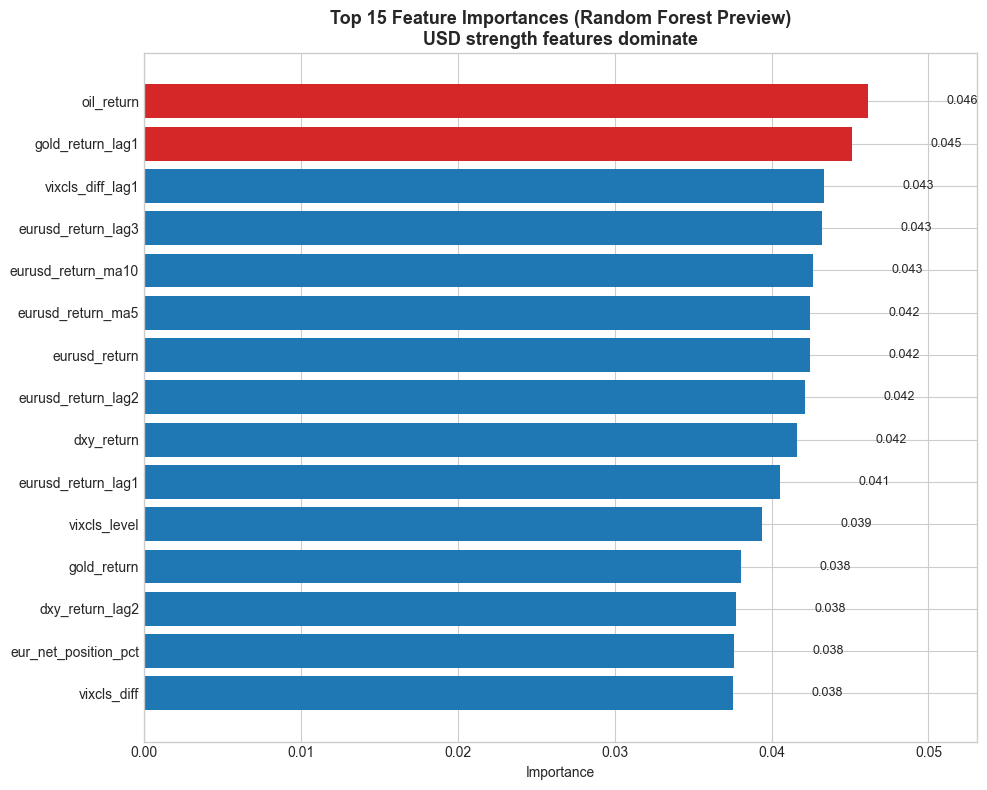

Saved: figures\features\04_feature_importance.png


In [13]:
"""
Visualize top 15 feature importances.
"""
top15 = importance.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d62728" if i >= 13 else "#1f77b4" for i in range(len(top15))]
ax.barh(top15["feature"], top15["importance"], color=colors)

for i, (feat_name, imp) in enumerate(zip(top15["feature"], top15["importance"])):
    ax.text(imp + 0.005, i, f"{imp:.3f}", va="center", fontsize=9)

ax.set_xlabel("Importance")
ax.set_title("Top 15 Feature Importances (Random Forest Preview)\n"
             "USD strength features dominate",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, max(top15["importance"]) * 1.15)
plt.tight_layout()

fig_path = FIG_DIR / "04_feature_importance.png"
plt.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

## 12. Save Features to Disk

Save the engineered features (with target) for use in modeling notebooks.

We save the **full feature set** (before split) — the modeling notebooks will re-apply the chronological split consistently.

In [14]:
"""
Save engineered features to data/processed/.
"""
output_path = PROCESSED_DIR / "fx_features.csv"
feat_clean.to_csv(output_path, index=False)

print(f"Saved features: {output_path.relative_to(PROJECT_ROOT)}")
print(f"Shape: {feat_clean.shape}")
print(f"Rows: {len(feat_clean)} (clean, no NaN)")
print(f"Features: {len(feature_cols)}")
print(f"Date range: {feat_clean['date'].min().date()} -> {feat_clean['date'].max().date()}")

importance_path = PROCESSED_DIR / "feature_importance_preview.csv"
importance.to_csv(importance_path, index=False)
print(f"\nSaved importance ranking: {importance_path.relative_to(PROJECT_ROOT)}")

print(f"\nSplit boundaries (for modeling notebooks):")
print(f"  train_end = '2022-01-01'")
print(f"  val_end   = '2025-01-01'")

Saved features: data\processed\fx_features.csv
Shape: (4084, 34)
Rows: 4084 (clean, no NaN)
Features: 31
Date range: 2010-02-02 -> 2026-05-12

Saved importance ranking: data\processed\feature_importance_preview.csv

Split boundaries (for modeling notebooks):
  train_end = '2022-01-01'
  val_end   = '2025-01-01'


## Conclusion

### Feature Engineering Complete

Created **31 features** in 6 groups:
- Returns (price series)
- Differences (rates/indices)
- Raw features (VIX level, COT)
- Lag features (momentum)
- Rolling statistics (MA, volatility)
- Engineered (rate spread, inflation diff, VIX regime, day of week)

Created **target** (next-day direction)  
**Chronological split** (train 73%, val 18%, test 8%)  
**Feature importance** highlighted: DXY return dominates (52%)

### Output Files

- `data/processed/fx_features.csv` — 4085 rows × 31 features + target
- `data/processed/feature_importance_preview.csv` — ranking
- `figures/features/04_feature_importance.png` — chart

### Key Insight for Modeling

USD strength (dxy_return + dtwexbgs) accounts for **66% of predictive importance**. This confirms economic theory: EUR/USD direction is dominated by USD movements.

### Next Steps

**`05_baseline_models.ipynb`** — Train and compare ML models (Random Forest, XGBoost, LightGBM), then DL models (LSTM, GRU).